**PART A**
## THEORY
#providing explanation of tensors using numpy

In [1]:
# 0D tensor / scaler
import numpy as np
scaler=np.array(10)
print(scaler)
print(scaler.shape)


10
()


In [2]:

# 1D tensor/vector
vector=np.array([1,2,3])
print(vector)
print(vector.shape)


[1 2 3]
(3,)


In [3]:
# 2D tensor/matrix
mat=np.array([[1,2,3],[4,5,6]])
print(mat)
print(mat.shape)


[[1 2 3]
 [4 5 6]]
(2, 3)


In [4]:
# 3D tensor/3D matrix
tensor_3d=np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
print(tensor_3d)
print(tensor_3d.shape)

[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
(2, 2, 2)


**PART B**

# DATA** **AQUISITION**

## LOAD CSV FILE

In [5]:
import pandas as pd
df_csv=pd.read_csv('/content/customer_churn_dataset_dataprofile_pr1.csv')
df_csv.head()

,Customer_ID,Age,Gender,City,Purchase_Frequency,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Support_Tickets,Discount_Used,Payment_Method,Churn,Source
0,1001,24,Male,Surat,Monthly,3,1850.0,12,1.0,No,UPI,No,CSV
1,1002,31,Female,Mumbai,Weekly,18,2450.0,5,0.0,Yes,Card,No,CSV
2,1003,45,Male,Delhi,Rarely,2,950.0,120,4.0,No,Cash,Yes,CSV
3,1004,28,Female,Pune,Monthly,7,1750.0,35,1.0,Yes,UPI,No,CSV
4,1005,52,Male,Ahmedabad,Rarely,1,700.0,180,5.0,No,Cash,Yes,CSV


## LOAD JSON FILE

In [6]:
import json
df_json=pd.read_json("//content/customer_churn_dataset_dataprofile_pr1.json")
df_json.head()

,Customer_ID,Age,Gender,City,Purchase_Frequency,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Support_Tickets,Discount_Used,Payment_Method,Churn,Source
0,1001,24,Male,Surat,Monthly,3,1850.0,12,1.0,No,UPI,No,CSV
1,1002,31,Female,Mumbai,Weekly,18,2450.0,5,0.0,Yes,Card,No,CSV
2,1003,45,Male,Delhi,Rarely,2,950.0,120,4.0,No,Cash,Yes,CSV
3,1004,28,Female,Pune,Monthly,7,1750.0,35,1.0,Yes,UPI,No,CSV
4,1005,52,Male,Ahmedabad,Rarely,1,700.0,180,5.0,No,Cash,Yes,CSV


In [7]:
import sqlite3

con = sqlite3.connect(':memory:')

with open("/content/customer_churn_dataset_dataprofile_pr1.sql", 'r') as f:
    sql_script = f.read()

con.executescript(sql_script)

df_query = pd.read_sql("SELECT * FROM customer_churn LIMIT 10", con)
print(df_query)

con.close()

   Customer_ID  Age  Gender       City Purchase_Frequency  Total_Purchases  \
0         1001   24    Male      Surat            Monthly                3   
1         1002   31  Female     Mumbai             Weekly               18   
2         1003   45    Male      Delhi             Rarely                2   
3         1004   28  Female       Pune            Monthly                7   
4         1005   52    Male  Ahmedabad             Rarely                1   
5         1006   36  Female  Bengaluru             Weekly               22   
6         1007   29    Male      Surat            Monthly                9   
7         1008   41  Female     Jaipur             Rarely                3   
8         1009   23    Male       Pune             Weekly               15   
9         1010   48  Female      Delhi             Rarely                2   

   Average_Order_Value  Days_Since_Last_Purchase  Support_Tickets  \
0                 1850                        12              1.0   
1  

## fetch API

In [25]:
import requests


url = "https://products-machphfwwi.mock.tool.postman.dev/products"

response = requests.get(url)

data = response.json()

df_json = pd.DataFrame(data)

df_json.head()

df_clean = pd.json_normalize(df_json["data"])

# Display the clean dataset
df_clean.head()

,Age,Average_Order_Value,Churn,City,Customer_ID,Days_Since_Last_Purchase,Discount_Used,Gender,Payment_Method,Purchase_Frequency,Source,Support_Tickets,Total_Purchases,id
0,24,1850.0,No,Surat,1001,12,No,Male,UPI,Monthly,CSV,1.0,3,1
1,31,2450.0,No,Mumbai,1002,5,Yes,Female,Card,Weekly,CSV,0.0,18,2
2,45,950.0,Yes,Delhi,1003,120,No,Male,Cash,Rarely,CSV,4.0,2,3
3,28,1750.0,No,Pune,1004,35,Yes,Female,UPI,Monthly,CSV,1.0,7,4
4,52,700.0,Yes,Ahmedabad,1005,180,No,Male,Cash,Rarely,CSV,5.0,1,5


# **PART C DATA UNDESTANDING AND CLEANING**
##6. initial exploration (working on csv file)

In [9]:
df_csv

,Customer_ID,Age,Gender,City,Purchase_Frequency,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Support_Tickets,Discount_Used,Payment_Method,Churn,Source
0,1001,24,Male,Surat,Monthly,3,1850.0,12,1.0,No,UPI,No,CSV
1,1002,31,Female,Mumbai,Weekly,18,2450.0,5,0.0,Yes,Card,No,CSV
2,1003,45,Male,Delhi,Rarely,2,950.0,120,4.0,No,Cash,Yes,CSV
3,1004,28,Female,Pune,Monthly,7,1750.0,35,1.0,Yes,UPI,No,CSV
4,1005,52,Male,Ahmedabad,Rarely,1,700.0,180,5.0,No,Cash,Yes,CSV
5,1006,36,Female,Bengaluru,Weekly,22,3200.0,3,0.0,Yes,Card,No,CSV
6,1007,29,Male,Surat,Monthly,9,2100.0,28,NaN,Yes,UPI,No,CSV
7,1008,41,Female,Jaipur,Rarely,3,1100.0,95,3.0,No,Card,Yes,CSV
8,1009,23,Male,Pune,Weekly,15,1950.0,7,0.0,Yes,UPI,No,JSON
9,1010,48,Female,Delhi,Rarely,2,850.0,150,4.0,No,Cash,Yes,JSON


In [10]:
#initial 10 enteries
df_csv.head(10)

,Customer_ID,Age,Gender,City,Purchase_Frequency,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Support_Tickets,Discount_Used,Payment_Method,Churn,Source
0,1001,24,Male,Surat,Monthly,3,1850.0,12,1.0,No,UPI,No,CSV
1,1002,31,Female,Mumbai,Weekly,18,2450.0,5,0.0,Yes,Card,No,CSV
2,1003,45,Male,Delhi,Rarely,2,950.0,120,4.0,No,Cash,Yes,CSV
3,1004,28,Female,Pune,Monthly,7,1750.0,35,1.0,Yes,UPI,No,CSV
4,1005,52,Male,Ahmedabad,Rarely,1,700.0,180,5.0,No,Cash,Yes,CSV
5,1006,36,Female,Bengaluru,Weekly,22,3200.0,3,0.0,Yes,Card,No,CSV
6,1007,29,Male,Surat,Monthly,9,2100.0,28,NaN,Yes,UPI,No,CSV
7,1008,41,Female,Jaipur,Rarely,3,1100.0,95,3.0,No,Card,Yes,CSV
8,1009,23,Male,Pune,Weekly,15,1950.0,7,0.0,Yes,UPI,No,JSON
9,1010,48,Female,Delhi,Rarely,2,850.0,150,4.0,No,Cash,Yes,JSON


In [11]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               31 non-null     int64  
 1   Age                       31 non-null     int64  
 2   Gender                    31 non-null     object 
 3   City                      31 non-null     object 
 4   Purchase_Frequency        31 non-null     object 
 5   Total_Purchases           31 non-null     int64  
 6   Average_Order_Value       30 non-null     float64
 7   Days_Since_Last_Purchase  31 non-null     int64  
 8   Support_Tickets           30 non-null     float64
 9   Discount_Used             30 non-null     object 
 10  Payment_Method            31 non-null     object 
 11  Churn                     31 non-null     object 
 12  Source                    31 non-null     object 
dtypes: float64(2), int64(4), object(7)
memory usage: 3.3+ KB


In [12]:
df_csv.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,31.0,1015.096774,8.941867,1001.0,1007.5,1015.0,1022.50,1030.0
Age,31.0,37.032258,9.931377,22.0,29.0,36.0,45.00,58.0
Total_Purchases,31.0,8.774194,7.269616,1.0,2.5,7.0,14.50,25.0
Average_Order_Value,30.0,1736.000000,810.757840,600.0,975.0,1775.0,2187.50,3500.0
Days_Since_Last_Purchase,31.0,64.838710,68.620744,2.0,8.5,35.0,115.00,240.0
Support_Tickets,30.0,2.033333,2.042367,0.0,0.0,1.0,3.75,7.0


In [13]:
# IDENTIFY MISSING VALUES AND DUBLICATES
df_csv.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Purchase_Frequency,0
Total_Purchases,0
Average_Order_Value,1
Days_Since_Last_Purchase,0
Support_Tickets,1
Discount_Used,1


In [14]:
df_csv.duplicated().sum()

np.int64(1)

In [15]:
df_csv.shape

(31, 13)

7 .**apply data** **cleaning**

In [16]:
# Missing values
df_csv['Average_Order_Value'].fillna(df_csv['Average_Order_Value'].median())
df_csv['Support_Tickets'].fillna(df_csv['Support_Tickets'].median())
df_csv['Discount_Used'].fillna(df_csv['Discount_Used'].mode()[0])

# Remove duplicates
df_csv.drop_duplicates(inplace=True)

# Correct data types
df_csv['Age'] = pd.to_numeric(df_csv['Age'], errors='coerce')
df_csv['Total_Purchases'] = pd.to_numeric(df_csv['Total_Purchases'], errors='coerce')

# Drop irrelevant column
# df_csv.drop(columns=['Customer_ID'])
print(df_csv.head())
print("Cleaning Completed!")

   Customer_ID  Age  Gender       City Purchase_Frequency  Total_Purchases  \
0         1001   24    Male      Surat            Monthly                3   
1         1002   31  Female     Mumbai             Weekly               18   
2         1003   45    Male      Delhi             Rarely                2   
3         1004   28  Female       Pune            Monthly                7   
4         1005   52    Male  Ahmedabad             Rarely                1   

   Average_Order_Value  Days_Since_Last_Purchase  Support_Tickets  \
0               1850.0                        12              1.0   
1               2450.0                         5              0.0   
2                950.0                       120              4.0   
3               1750.0                        35              1.0   
4                700.0                       180              5.0   

  Discount_Used Payment_Method Churn Source  
0            No            UPI    No    CSV  
1           Yes         

**PART D (EDA) EXPLORATORY DATA ANALYSIS**
## PERFORM Univariate analysis

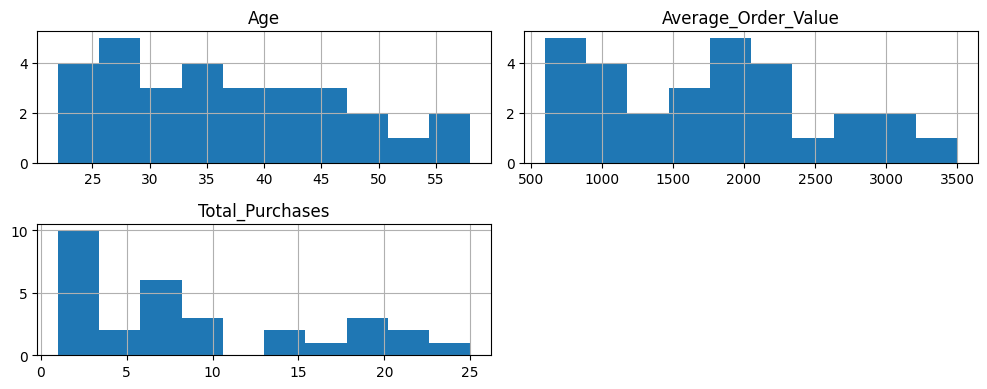

In [17]:
import matplotlib.pyplot as plt

df_csv[['Age', 'Average_Order_Value', 'Total_Purchases']].hist(
    bins=10, figsize=(10, 4)
)

plt.tight_layout()
plt.title('age dstribution')
plt.show()

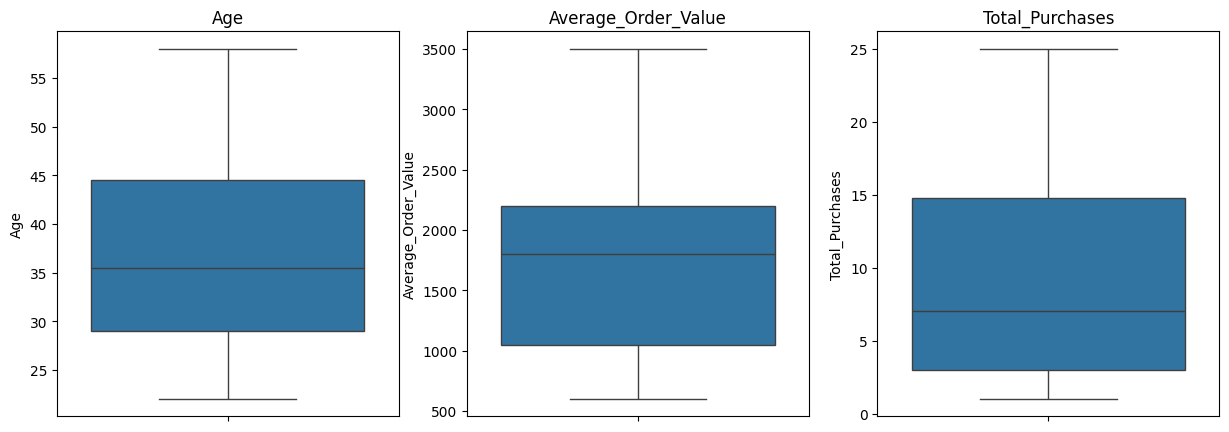

In [18]:
import seaborn as sns
# boxplot
fig,axes=plt.subplots(1,3,figsize=(15,5))
sns.boxplot(df_csv["Age"], ax=axes[0])
sns.boxplot(df_csv["Average_Order_Value"], ax=axes[1])
sns.boxplot(df_csv["Total_Purchases"],  ax=axes[2])
axes[0].set_title("Age")
axes[1].set_title("Average_Order_Value")
axes[2].set_title("Total_Purchases")
plt.show()

perform bivarite analysis

realtionship between gender vs average order value

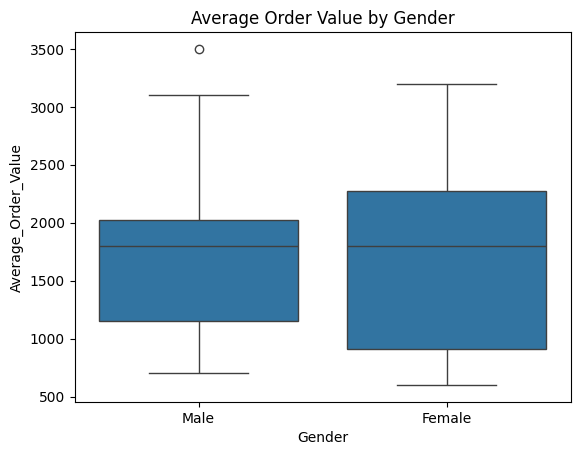

In [19]:
sns.boxplot(x='Gender', y='Average_Order_Value', data=df_csv)
plt.title('Average Order Value by Gender')
plt.show()

## RELATIONSHIP BETWEEN TOTAL PURCHASES VS  CHURN

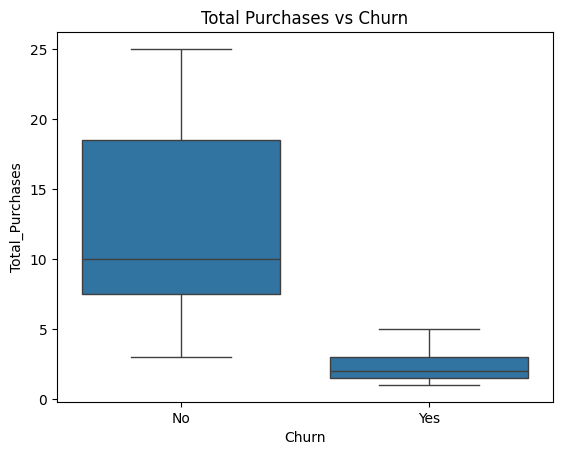

In [20]:
sns.boxplot(x='Churn', y='Total_Purchases', data=df_csv)
plt.title('Total Purchases vs Churn')
plt.show()

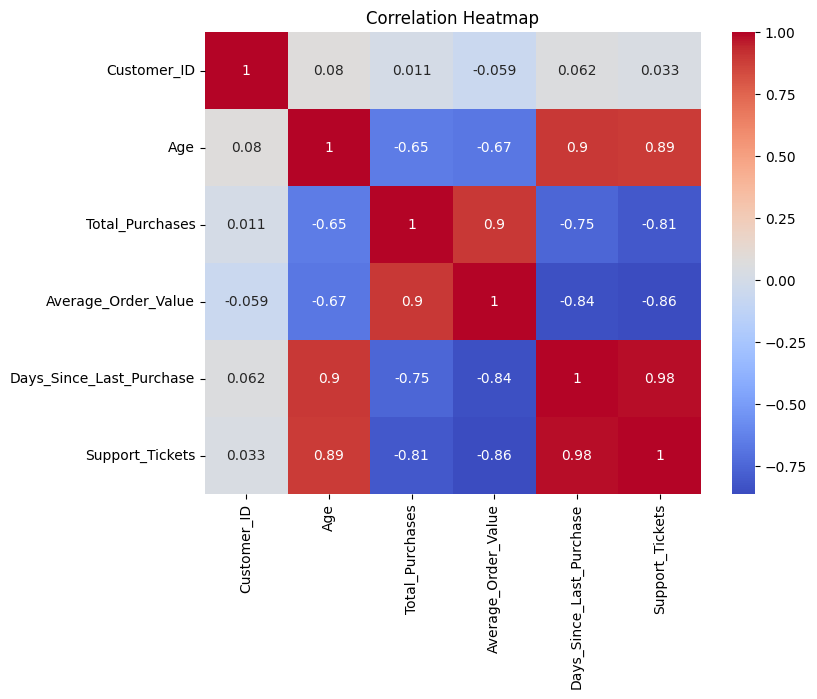

In [21]:

import matplotlib.pyplot as plt

num_cols = df_csv.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

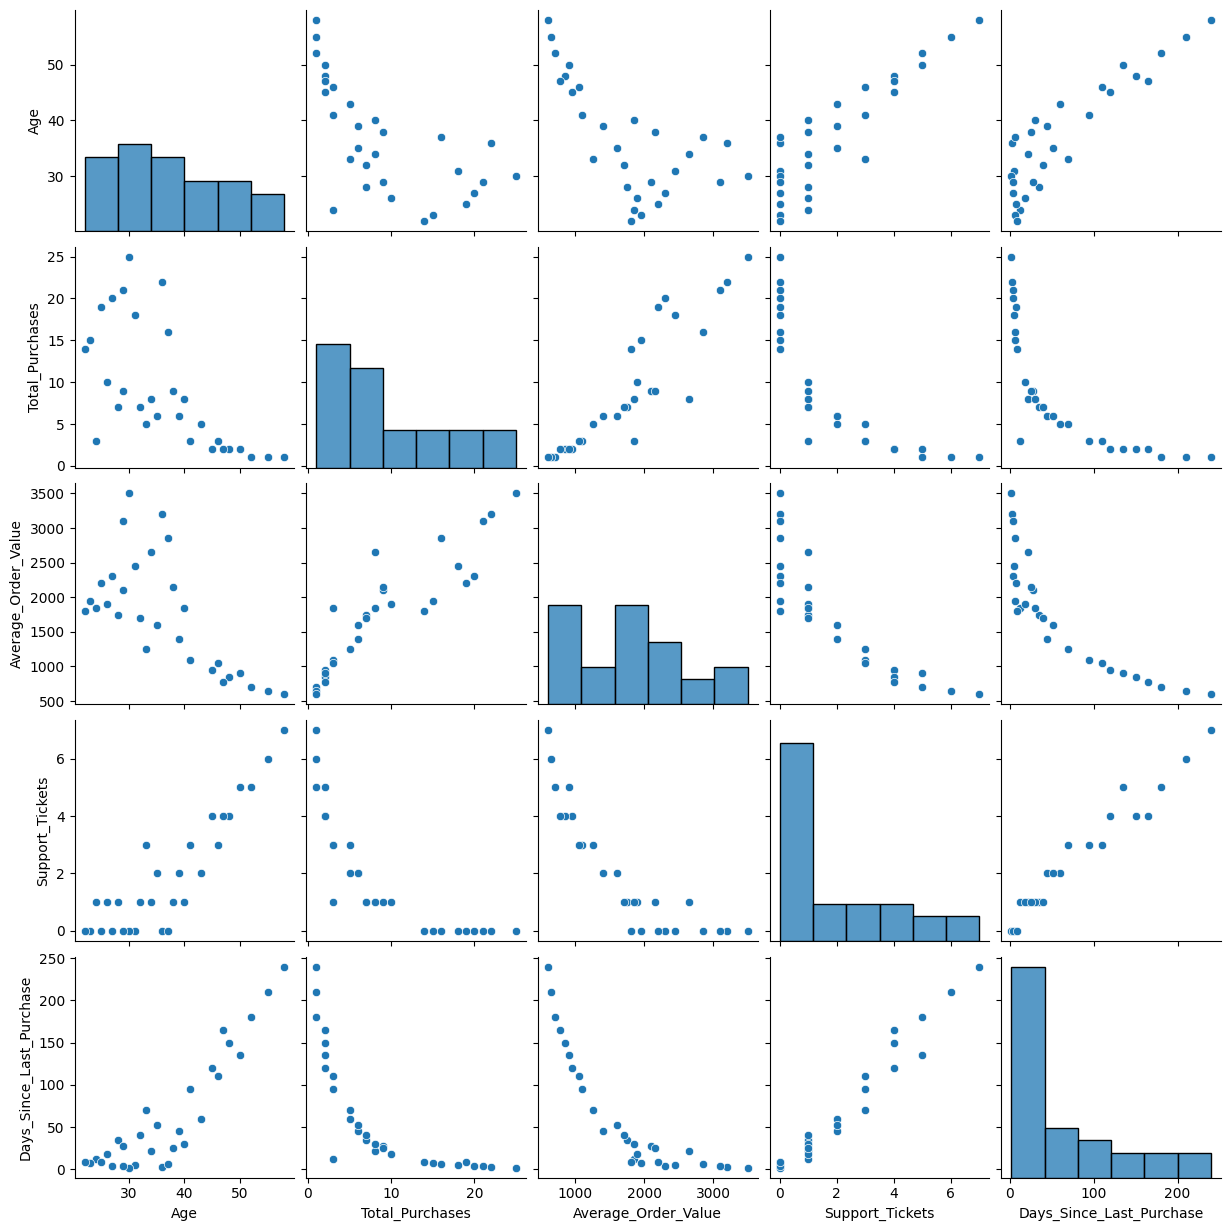

In [22]:
# pairplot to identify feature interactions
sns.pairplot(df_csv,vars=['Age', 'Total_Purchases', 'Average_Order_Value','Support_Tickets','Days_Since_Last_Purchase'])

**PART E DATA PROFILING**

In [23]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile=ProfileReport(df_csv)
profile.to_file(output_file='customer_churn_profiling_report.html')
print('PROFILE REPORT GENERATTED SUCCESSFULLY')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00


/tmp/ipykernel_1440/818413897.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 23.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

PROFILE REPORT GENERATTED SUCCESSFULLY
